# Import dependencies

In [ ]:
import os
import torch
import torchaudio
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

torch.device("cuda" if torch.cuda.is_available() else "cpu")

True
NVIDIA GeForce RTX 5090 Laptop GPU


device(type='cuda')

# Load Dataset and split into Testing and Training

In [2]:
from coffee_speech_dataset import CoffeeSpeechDataset
from torch.utils.data import DataLoader
import torchaudio.transforms as T

# Define transform (optional but recommended)
transform = T.MelSpectrogram(
    sample_rate=16000,
    n_mels=64,
    n_fft=400,       # 25ms window — standard for speech
    hop_length=160,  # 10ms hop — fine enough to catch short phonemes
    f_min=20,        # cut sub-bass noise
    f_max=8000,      # Nyquist for 16kHz, no energy above this anyway
    power=2.0        # power spectrogram (vs magnitude)
)

# Load dataset
dataset = CoffeeSpeechDataset(
    root_dir="data",
    sample_rate=16000,
    transform=transform
)

# Create DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

# Check dataset
print(f"Classes:  {dataset.label_names}")
print(f"Samples:  {len(dataset)}")
print(f"Batches:  {len(dataloader)}")




Classes:  ['kaffee_gross', 'kaffee_klein', 'ok_fernando']
Samples:  6750
Batches:  211


In [3]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=1, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_set,   batch_size=1, shuffle=False, num_workers=4)

print(f"Train: {len(train_set)} | Val: {len(val_set)}")

Train: 5400 | Val: 1350


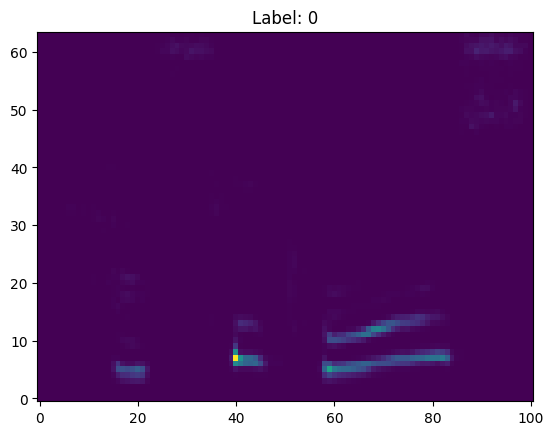

In [4]:
import matplotlib.pyplot as plt
mel, label = next(iter(train_loader))
plt.imshow(mel[0][0].cpu().numpy(), aspect='auto', origin='lower')
plt.title(f"Label: {label[0]}")
plt.show()

# Minimal CNN Architecture

In [ ]:
class DSCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.model = nn.Sequential(
            # Standard conv first
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Depthwise separable blocks
            self._ds_block(32, 32),
            self._ds_block(32, 32),
            self._ds_block(32, 32),
            self._ds_block(32, 32),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(32, num_classes)
        )

    def _ds_block(self, in_ch, out_ch):
        return nn.Sequential(
            # Depthwise
            nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1, groups=in_ch),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(),
            # Pointwise
            nn.Conv2d(in_ch, out_ch, kernel_size=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.model(x)